## **7° Module**: TT - Sampling Noise & Embedding Concentration
* September 23°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Two measurements made on the night of 22 September have to be redone.

- The **shot-sensitivity study** (figure E3) compared shot-based estimates from Aer
  against an exact statevector reference. The error stopped shrinking at about
  $0.013$ even at a million shots, and that floor was recorded as a systematic bias
  of the simulator (H-016).
- The **embedding concentration sweep** (figure E4, H-018) measured how the spread
  of $\langle Z_i \rangle$ across inputs changes with the number of qubits and of
  variational layers.

Both relied on the same "exact" reference: an `EstimatorQNN` running on a
`StatevectorEstimator`. This notebook shows that the reference was not exact,
identifies why, and repeats both measurements.

1. Where does the $0.013$ floor come from?
2. What does Aer's estimator actually do when it is given a `precision`?
3. How does the error of a **genuinely sampled** $\langle Z_i \rangle$ scale with shots?
4. Does the embedding concentration of H-018 survive once the noise is removed?

#### **1° Setup**

**a.** Import the necessary libraries

In [1]:
import time
import inspect
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator, SamplerV2 as AerSampler
from qiskit_machine_learning.neural_networks import EstimatorQNN

warnings.filterwarnings("ignore")
logging.getLogger("qiskit_machine_learning").setLevel(logging.ERROR)
sns.set_style("whitegrid")

import qiskit, qiskit_aer, qiskit_machine_learning
print("Environment:")
print(f"  qiskit                   : {qiskit.__version__}")
print(f"  qiskit-aer               : {qiskit_aer.__version__}")
print(f"  qiskit-machine-learning  : {qiskit_machine_learning.__version__}")
print(f"  numpy                    : {np.__version__}")

Environment:
  qiskit                   : 2.3.0
  qiskit-aer               : 0.17.2
  qiskit-machine-learning  : 0.9.0
  numpy                    : 2.2.6


**b.** Configuration

In [2]:
SEED = 42
RESULTS_DIR = Path("/Users/alexander_san/TT/Code/results")
FIG_DIR = Path("/Users/alexander_san/TT/Docs/Figures")

# Operating point of the experiment (D-013)
K, REPS = 12, 1

# Same inputs and theta as the overnight shot study: first two draws of a seed-42 stream
rng = np.random.default_rng(SEED)
X_ref = rng.uniform(0, np.pi, (16, K))
w_ref = rng.uniform(0, 2 * np.pi, (REPS + 1) * K)

# Shot study: the grid reaches 2^20 because H-016 reported its floor up to there
SHOTS_GRID = [512, 1024, 2048, 4096, 8192, 16384, 65536, 262144, 1048576]
N_REPEATS = 10

# Library default that turns out to matter, read from the installed version
QNN_DEFAULT_PRECISION = inspect.signature(EstimatorQNN.__init__).parameters["default_precision"].default

# Concentration sweep: identical to the overnight run of H-018
K_VALUES, REPS_VALUES = (8, 12, 16), (1, 2, 3)
N_THETA, N_SAMP = 10, 100

**c.** Circuit and three ways of reading $\langle Z_i \rangle$

Keeping these three apart is the point of the notebook:

- `exact_z` evolves the statevector directly with `qiskit.quantum_info.Statevector`.
  No primitive and no precision argument, so nothing can inject noise. This is the
  ground truth.
- `qnn_z` goes through `EstimatorQNN`, the path used by notebooks 5 and 6 and by the
  overnight scripts.
- `sampled_z` measures the circuit $n$ times with Aer's **sampler** and estimates each
  $\langle Z_i \rangle$ from the bitstrings, as a quantum device would.

The sampled estimator follows from the measurement postulate. Each shot returns a bit
$b_i \in \{0, 1\}$ with $P(b_i = 0) = p_i = (1 + \langle Z_i \rangle)/2$, so

$$\hat{Z}_i = 1 - \frac{2}{n}\sum_{s=1}^{n} b_i^{(s)}, \qquad
\operatorname{Var}(\hat{Z}_i) = \frac{4\,p_i(1 - p_i)}{n} = \frac{1 - \langle Z_i \rangle^2}{n}.$$

That variance is a property of quantum measurement, not of any library.

In [3]:
def build_circuit(k, reps):
    # Feature map + fixed ansatz, as in Module 5 (D-013, D-014)
    fm, ans = zz_feature_map(k, reps=1), real_amplitudes(k, reps=reps)
    qc = QuantumCircuit(k)
    qc.compose(fm, inplace=True)
    qc.compose(ans, inplace=True)
    return qc, list(fm.parameters), list(ans.parameters)


def z_observables(k):
    return [SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=k) for i in range(k)]


def bind_values(qc, in_p, w_p, X, w):
    # Parameter values in the order the primitives expect, which is qc.parameters
    rows = []
    for x in X:
        m = dict(zip(in_p, x)) | dict(zip(w_p, w))
        rows.append([m[p] for p in qc.parameters])
    return np.array(rows)


def exact_z(qc, in_p, w_p, X, w):
    # Ground truth: direct statevector evolution, no primitive involved
    obs = z_observables(qc.num_qubits)
    out = []
    for x in X:
        sv = Statevector(qc.assign_parameters(dict(zip(in_p, x)) | dict(zip(w_p, w))))
        out.append([sv.expectation_value(o).real for o in obs])
    return np.array(out)


def qnn_z(qc, in_p, w_p, X, w, estimator, **kw):
    # <Z_i> through EstimatorQNN, the path used by notebooks 5 and 6
    qnn = EstimatorQNN(circuit=qc, input_params=in_p, weight_params=w_p,
                       observables=z_observables(qc.num_qubits),
                       estimator=estimator, input_gradients=False, **kw)
    return qnn.forward(X, w)


def z_from_bits(bitarray, k):
    # <Z_i> = P(bit_i = 0) - P(bit_i = 1), one row per parameter set
    out = np.empty(bitarray.shape + (k,))
    for loc in np.ndindex(bitarray.shape):
        # Qiskit is little-endian: the last bit of each bitstring is qubit 0
        bits = np.unpackbits(bitarray.array[loc], axis=-1)[:, -k:][:, ::-1]
        out[loc] = 1.0 - 2.0 * bits.mean(axis=0)
    return out


def sampled_z(qc, in_p, w_p, X, w, shots):
    # <Z_i> estimated from `shots` genuine measurements per input
    qm = qc.copy()
    qm.measure_all()
    result = AerSampler().run([(qm, bind_values(qc, in_p, w_p, X, w))], shots=shots).result()
    return z_from_bits(result[0].data.meas, qc.num_qubits)


qc12, in12, w12 = build_circuit(K, REPS)

# Bit-order check: X on qubit 0 only must read <Z> = (-1, +1, +1)
t = QuantumCircuit(3)
t.x(0)
t.measure_all()
check = z_from_bits(AerSampler().run([t], shots=64).result()[0].data.meas, 3)
assert np.allclose(check, [-1, 1, 1]), check
print(f"Bit order verified: {check}")
print(f"EstimatorQNN default precision: {QNN_DEFAULT_PRECISION}  (= 1/sqrt({round(QNN_DEFAULT_PRECISION**-2)}))")

Bit order verified: [-1.  1.  1.]
EstimatorQNN default precision: 0.015625  (= 1/sqrt(4096))


#### **2° Where does the 0.013 floor come from?**

**a.** The question

In H-016 the error between Aer and the statevector reference stopped shrinking at
about $0.013$, even at $10^6$ shots. A sampling error cannot behave like that, so
either Aer is biased or the reference is not what it claims to be.

Two library defaults are relevant:

- `EstimatorQNN` is constructed with `default_precision=0.015625` and passes it to
  `estimator.run()` on every forward pass. It is the same line found in H-014.
- `StatevectorEstimator`, when it receives a non-zero precision, does **not** return
  the exact value: it adds Gaussian noise $\mathcal{N}(0, \text{precision})$ to mimic
  a finite number of shots.

If both hold, the overnight "exact" reference carried noise with
$\sigma = 0.015625 = 1/\sqrt{4096}$. For a Gaussian error
$\mathbb{E}|e| = \sigma\sqrt{2/\pi}$, so the floor should sit at
$0.015625\sqrt{2/\pi} = 0.01247$. The check below evaluates the circuit, inputs and
$\theta$ of the overnight run in five ways.

In [4]:
truth = exact_z(qc12, in12, w12, X_ref, w_ref)
mae = lambda a, b: float(np.abs(a - b).mean())

ref_night = qnn_z(qc12, in12, w12, X_ref, w_ref, StatevectorEstimator())
ref_again = qnn_z(qc12, in12, w12, X_ref, w_ref, StatevectorEstimator())
sv_zero = qnn_z(qc12, in12, w12, X_ref, w_ref, StatevectorEstimator(), default_precision=0.0)
aer_zero = qnn_z(qc12, in12, w12, X_ref, w_ref, AerEstimator(), default_precision=0.0)
aer_1m = qnn_z(qc12, in12, w12, X_ref, w_ref, AerEstimator(), default_precision=1 / np.sqrt(2**20))

floor = pd.DataFrame([
    ("QNN + Statevector, default precision", "truth", mae(ref_night, truth), np.sqrt(2 / np.pi) * QNN_DEFAULT_PRECISION),
    ("QNN + Statevector, default precision", "itself, second call", mae(ref_night, ref_again), np.sqrt(2 / np.pi) * np.sqrt(2) * QNN_DEFAULT_PRECISION),
    ("QNN + Statevector, precision = 0", "truth", mae(sv_zero, truth), 0.0),
    ("QNN + Aer, precision = 0", "truth", mae(aer_zero, truth), 0.0),
    ("QNN + Aer, 2^20 shots", "truth", mae(aer_1m, truth), np.sqrt(2 / np.pi) / 2**10),
    ("QNN + Aer, 2^20 shots", "overnight reference", mae(aer_1m, ref_night), np.sqrt(2 / np.pi) * np.hypot(QNN_DEFAULT_PRECISION, 2**-10)),
], columns=["evaluation", "compared_with", "mae", "predicted"])
floor.to_csv(RESULTS_DIR / "7_origen_suelo_h016.csv", index=False)

with pd.option_context("display.float_format", "{:.3e}".format, "display.width", 120):
    print(floor.to_string(index=False))

                          evaluation       compared_with       mae  predicted
QNN + Statevector, default precision               truth 1.310e-02  1.247e-02
QNN + Statevector, default precision itself, second call 1.684e-02  1.763e-02
    QNN + Statevector, precision = 0               truth 0.000e+00  0.000e+00
            QNN + Aer, precision = 0               truth 1.693e-16  0.000e+00
               QNN + Aer, 2^20 shots               truth 8.863e-04  7.792e-04
               QNN + Aer, 2^20 shots overnight reference 1.315e-02  1.249e-02


**b.** Consequence

- Aer at precision $0$ agrees with the direct statevector to machine precision.
  **There is no simulator bias.**
- The reference was the noisy one. `EstimatorQNN` on a `StatevectorEstimator` at the
  default precision differs from the truth by $\sqrt{2/\pi}\cdot 0.015625$, and two
  identical calls do not even agree with each other. Aer at $2^{20}$ shots lands on
  the H-016 floor when compared with that reference, and on
  $\sqrt{2/\pi}/1024 \approx 7.8\times10^{-4}$ when compared with the truth.
- Every $\langle Z_i \rangle$ computed through `EstimatorQNN` without
  `default_precision=0.0` carries this noise. That includes the "exact" reference of
  section 5 of notebook 5 (`5_benchmark_shots.csv`) and the overnight concentration
  sweep of H-018, which section 5 below repeats. The timing measurements are
  unaffected: adding noise costs nothing.

The noise is not quantum. It is a library default that emulates a finite number of
shots, applied silently to a primitive whose name suggests exact simulation.

#### **3° What does Aer's estimator do with a precision?**

**a.** The question

A real measurement with $n$ shots can only return
$\hat{Z} \in \{-1, -1 + 2/n, \dots, 1\}$: a discrete set inside $[-1, 1]$.

Aer's `EstimatorV2` (`qiskit_aer/primitives/estimator_v2.py`) instead computes the
exact value with `save_expectation_value` and then executes
`evs = rng.normal(evs, precision)`. At a coarse precision the difference is visible:
with $16$ shots (precision $0.25$) genuinely sampled values must be multiples of
$1/8$ and can never leave $[-1, 1]$. Gaussian values are bound by neither constraint.

In [5]:
COARSE = 16
on_grid = lambda z: float(np.isclose((z + 1) * COARSE / 2, np.round((z + 1) * COARSE / 2)).mean())

aer_coarse = qnn_z(qc12, in12, w12, X_ref, w_ref, AerEstimator(), default_precision=1 / np.sqrt(COARSE))
smp_coarse = sampled_z(qc12, in12, w12, X_ref, w_ref, COARSE)

coarse = pd.DataFrame([
    ("Aer EstimatorV2, precision 0.25", on_grid(aer_coarse), float((np.abs(aer_coarse) > 1).mean()), len(np.unique(aer_coarse.round(12)))),
    ("Aer SamplerV2, 16 shots", on_grid(smp_coarse), float((np.abs(smp_coarse) > 1).mean()), len(np.unique(smp_coarse.round(12)))),
], columns=["evaluation", "fraction_on_1/8_grid", "fraction_outside_[-1,1]", "distinct_values"])
print(coarse.to_string(index=False))

                     evaluation  fraction_on_1/8_grid  fraction_outside_[-1,1]  distinct_values
Aer EstimatorV2, precision 0.25                   0.0                      0.0              192
        Aer SamplerV2, 16 shots                   1.0                      0.0               11


**b.** Consequence

Aer's `EstimatorV2` **does not sample**. It returns the exact expectation value plus a
Gaussian model of shot noise. Three things follow:

1. The slope of $-0.5065$ reported overnight for E3 was built in: the injected noise
   has $\sigma = \text{precision} = 1/\sqrt{\text{shots}}$ by definition. It confirms
   the model, not the statistics of measurement.
2. Here $\langle Z_i \rangle \approx 0$, so $(1 - \langle Z_i \rangle^2)/n \approx 1/n$
   and the Gaussian model happens to be numerically close to genuine sampling. It
   would not be for $|\langle Z_i \rangle|$ near $1$ or for few shots.
3. The instrument for the OE-6 shot study is the **sampler**. Section 4 uses it.

Separating the two layers again: the $1/\sqrt{n}$ law is a property of quantum
measurement; representing it as additive Gaussian noise is an implementation choice
of this simulator.

#### **4° Shot sensitivity with genuine sampling**

**a.** Measurement

Same circuit, inputs and $\theta$ as section 2. For every shot count the circuit is
sampled `N_REPEATS` times independently, and two quantities are compared against
their theoretical values:

- **Dispersion between repetitions**: the statistical spread of the estimator. Its
  theoretical value is $\sqrt{(1 - \langle Z_i \rangle^2)/n}$, averaged over the
  $16 \times 12 = 192$ outputs.
- **MAE against the truth**: the total error. Its theoretical value is
  $\sqrt{2/\pi}$ times the above, since the estimator is approximately normal.

If the H-016 bias were real, the MAE would stall. If the estimator is unbiased, it
keeps falling as $1/\sqrt{n}$ over the whole grid.

In [6]:
records = []
print(f"Genuine sampling, k={K} reps={REPS}, {N_REPEATS} repetitions per point")
for shots in SHOTS_GRID:
    t0 = time.perf_counter()
    runs = np.stack([sampled_z(qc12, in12, w12, X_ref, w_ref, shots) for _ in range(N_REPEATS)])
    sigma = np.sqrt((1 - truth**2) / shots)
    records.append({
        "shots": shots,
        "dispersion": runs.std(axis=0, ddof=1).mean(),
        "dispersion_teorica": sigma.mean(),
        "mae_vs_exacto": np.abs(runs - truth).mean(),
        "mae_teorico": np.sqrt(2 / np.pi) * sigma.mean(),
        "sesgo_medio": np.abs(runs.mean(axis=0) - truth).mean(),
        "sesgo_teorico": np.sqrt(2 / np.pi) * sigma.mean() / np.sqrt(N_REPEATS),
        "n_repeats": N_REPEATS,
        "segundos": time.perf_counter() - t0,
    })
    r = records[-1]
    print(f"  shots={shots:8d}  dispersion={r['dispersion']:.5f} (theory {r['dispersion_teorica']:.5f})  "
          f"MAE={r['mae_vs_exacto']:.5f} (theory {r['mae_teorico']:.5f})  {r['segundos']:.1f}s")

shots_df = pd.DataFrame(records)
shots_df.to_csv(RESULTS_DIR / "7_shots_muestreo_real.csv", index=False)

slope_disp = np.polyfit(np.log(shots_df.shots), np.log(shots_df.dispersion), 1)[0]
slope_mae = np.polyfit(np.log(shots_df.shots), np.log(shots_df.mae_vs_exacto), 1)[0]
print()
print(f"Log-log slope, dispersion : {slope_disp:.4f}   (theory -0.5)")
print(f"Log-log slope, MAE        : {slope_mae:.4f}   (theory -0.5)")

Genuine sampling, k=12 reps=1, 10 repetitions per point


  shots=     512  dispersion=0.04261 (theory 0.04416)  MAE=0.03489 (theory 0.03524)  0.4s


  shots=    1024  dispersion=0.02981 (theory 0.03123)  MAE=0.02441 (theory 0.02492)  0.4s


  shots=    2048  dispersion=0.02134 (theory 0.02208)  MAE=0.01735 (theory 0.01762)  0.7s


  shots=    4096  dispersion=0.01524 (theory 0.01561)  MAE=0.01247 (theory 0.01246)  1.0s


  shots=    8192  dispersion=0.01085 (theory 0.01104)  MAE=0.00890 (theory 0.00881)  1.7s


  shots=   16384  dispersion=0.00762 (theory 0.00781)  MAE=0.00625 (theory 0.00623)  3.4s


  shots=   65536  dispersion=0.00379 (theory 0.00390)  MAE=0.00312 (theory 0.00311)  11.3s


  shots=  262144  dispersion=0.00190 (theory 0.00195)  MAE=0.00156 (theory 0.00156)  44.6s


  shots= 1048576  dispersion=0.00095 (theory 0.00098)  MAE=0.00077 (theory 0.00078)  168.0s

Log-log slope, dispersion : -0.4986   (theory -0.5)
Log-log slope, MAE        : -0.4983   (theory -0.5)


**b.** Visualization

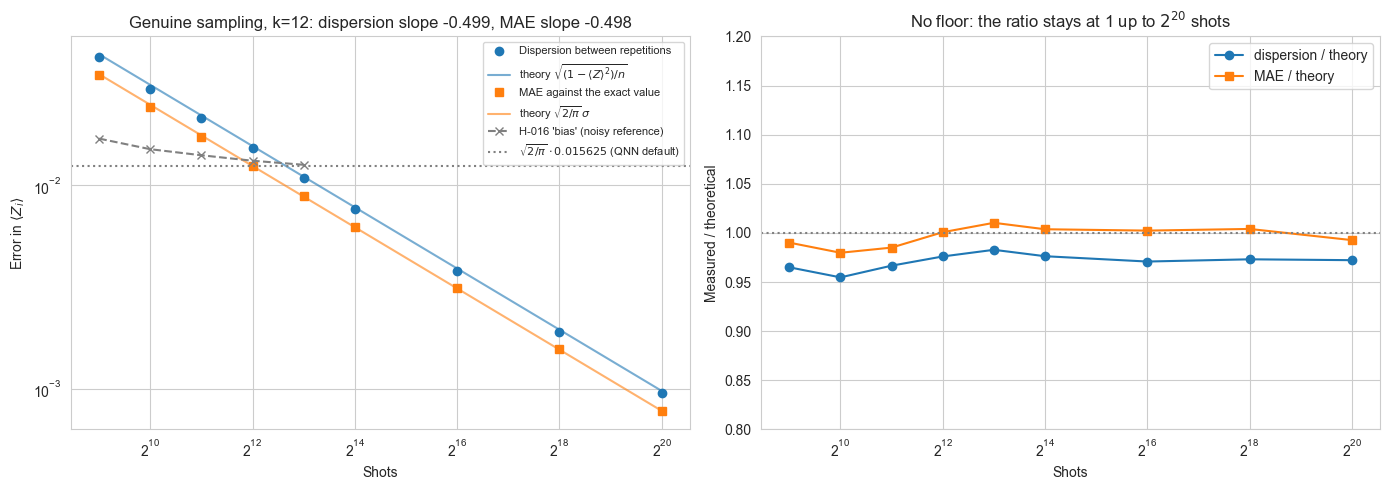

In [7]:
old = pd.read_csv(RESULTS_DIR / "7_shots_repetido.csv")
floor_pred = np.sqrt(2 / np.pi) * QNN_DEFAULT_PRECISION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(shots_df.shots, shots_df.dispersion, "o", color="C0", label="Dispersion between repetitions")
ax.plot(shots_df.shots, shots_df.dispersion_teorica, "-", color="C0", alpha=0.6, label=r"theory $\sqrt{(1-\langle Z\rangle^2)/n}$")
ax.plot(shots_df.shots, shots_df.mae_vs_exacto, "s", color="C1", label="MAE against the exact value")
ax.plot(shots_df.shots, shots_df.mae_teorico, "-", color="C1", alpha=0.6, label=r"theory $\sqrt{2/\pi}\,\sigma$")
ax.plot(old.shots, old.sesgo_vs_statevector, "x--", color="gray", label="H-016 'bias' (noisy reference)")
ax.axhline(floor_pred, color="gray", ls=":", label=r"$\sqrt{2/\pi}\cdot 0.015625$ (QNN default)")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Shots")
ax.set_ylabel(r"Error in $\langle Z_i \rangle$")
ax.set_title(f"Genuine sampling, k={K}: dispersion slope {slope_disp:.3f}, MAE slope {slope_mae:.3f}")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(shots_df.shots, shots_df.dispersion / shots_df.dispersion_teorica, "o-", label="dispersion / theory")
ax.plot(shots_df.shots, shots_df.mae_vs_exacto / shots_df.mae_teorico, "s-", label="MAE / theory")
ax.axhline(1.0, color="gray", ls=":")
ax.set_xscale("log", base=2)
ax.set_ylim(0.8, 1.2)
ax.set_xlabel("Shots")
ax.set_ylabel("Measured / theoretical")
ax.set_title("No floor: the ratio stays at 1 up to $2^{20}$ shots")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "E3_shots_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

**c.** Consequence

With genuine sampling both the dispersion and the total error follow
$\sqrt{(1 - \langle Z_i \rangle^2)/n}$ over the whole grid, from $512$ to $2^{20}$
shots, and the mean of the repetitions converges to the exact value. **There is no
floor.**

The dispersion sits consistently at about $0.97$ of its theoretical value rather than at
$1$. That is not a property of the simulator but of the statistic: the sample standard
deviation of $10$ repetitions underestimates $\sigma$ by the factor
$c_4(10) = 0.973$. The MAE, which does not go through a standard deviation, sits at $1$. The simulator reproduces the statistics of quantum measurement, which is
what OE-6 needs to show; the $0.013$ of H-016 was the QNN default precision
$0.015625$ multiplied by $\sqrt{2/\pi}$.

For Module 5 this fixes a rule: embeddings are computed with exact expectation values,
and exact means either `Statevector` directly or a primitive called with precision
$0$. Architecture B needs no gradients, so it does not need `EstimatorQNN` at all.

#### **5° Embedding concentration with exact values**

**a.** Measurement

H-018 measured the standard deviation of $\langle Z_i \rangle$ across $100$ inputs,
averaged over $10$ draws of $\theta$, through `EstimatorQNN` at the default precision.
Independent noise adds in quadrature,

$$s_{\text{measured}}^2 \approx s_{\text{true}}^2 + 0.015625^2,$$

so the distortion grows as the true dispersion shrinks: precisely in the wide and
deep configurations the sweep is about.

The sweep below is identical to the overnight one, with the same seed and the same
order of draws, and **precision $0$ is the only change**. As a consistency check, the
default noise is then added back to the exact values with a separate generator: if
the diagnosis is right, that should reproduce the overnight numbers.

> This cell takes about an hour, almost all of it at $k = 16$.

In [8]:
rng_c = np.random.default_rng(SEED)          # same stream as the overnight sweep
rng_noise = np.random.default_rng(SEED + 1)  # separate stream for the consistency check
rows = []
print(f"Exact values, averaged over {N_THETA} draws of theta, {N_SAMP} inputs each")
for k in K_VALUES:
    Xc = rng_c.uniform(0, np.pi, (N_SAMP, k))
    for reps in REPS_VALUES:
        qc, in_p, w_p = build_circuit(k, reps)
        stds, stds_noisy, t0 = [], [], time.perf_counter()
        for _ in range(N_THETA):
            w = rng_c.uniform(0, 2 * np.pi, len(w_p))
            Z = qnn_z(qc, in_p, w_p, Xc, w, StatevectorEstimator(), default_precision=0.0)
            stds.append(Z.std(axis=0).mean())
            stds_noisy.append((Z + rng_noise.normal(0, QNN_DEFAULT_PRECISION, Z.shape)).std(axis=0).mean())
        stds, stds_noisy = np.array(stds), np.array(stds_noisy)
        rows.append(dict(k=k, reps=reps, n_weights=len(w_p), n_theta=N_THETA,
                         std_media=stds.mean(), std_de_std=stds.std(),
                         std_min=stds.min(), std_max=stds.max(),
                         std_media_con_ruido_simulado=stds_noisy.mean(),
                         segundos=time.perf_counter() - t0))
        print(f"  k={k:2d} reps={reps}  std={stds.mean():.4f} +/- {stds.std():.4f}  "
              f"[{stds.min():.4f}, {stds.max():.4f}]  ({rows[-1]['segundos']:.0f}s)", flush=True)

conc = pd.DataFrame(rows)
conc.to_csv(RESULTS_DIR / "7_concentracion_embedding.csv", index=False)

Exact values, averaged over 10 draws of theta, 100 inputs each


  k= 8 reps=1  std=0.0837 +/- 0.0131  [0.0695, 0.1093]  (16s)


  k= 8 reps=2  std=0.0833 +/- 0.0091  [0.0715, 0.0989]  (20s)


  k= 8 reps=3  std=0.0718 +/- 0.0052  [0.0646, 0.0829]  (48s)


  k=12 reps=1  std=0.0417 +/- 0.0068  [0.0305, 0.0497]  (139s)


  k=12 reps=2  std=0.0544 +/- 0.0036  [0.0475, 0.0599]  (109s)


  k=12 reps=3  std=0.0305 +/- 0.0044  [0.0227, 0.0360]  (106s)


  k=16 reps=1  std=0.0363 +/- 0.0090  [0.0252, 0.0569]  (2892s)


  k=16 reps=2  std=0.0367 +/- 0.0043  [0.0291, 0.0432]  (1714s)


  k=16 reps=3  std=0.0161 +/- 0.0023  [0.0134, 0.0198]  (1365s)


**b.** Comparison with the overnight run

In [9]:
night = pd.read_csv(RESULTS_DIR / "7_concentracion_embedding_ruido_qnn.csv")
cmp_df = conc[["k", "reps", "std_media", "std_de_std", "std_media_con_ruido_simulado"]].merge(
    night[["k", "reps", "std_media", "std_de_std"]], on=["k", "reps"], suffixes=("_exacto", "_noche"))
cmp_df["inflacion_%"] = 100 * (cmp_df.std_media_noche / cmp_df.std_media_exacto - 1)
cmp_df["ruido_en_varianza_%"] = 100 * QNN_DEFAULT_PRECISION**2 / cmp_df.std_media_noche**2
cmp_df = cmp_df[["k", "reps", "std_media_noche", "std_media_con_ruido_simulado", "std_media_exacto",
                 "std_de_std_noche", "std_de_std_exacto", "inflacion_%", "ruido_en_varianza_%"]]
with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 160):
    print(cmp_df.to_string(index=False))

 k  reps  std_media_noche  std_media_con_ruido_simulado  std_media_exacto  std_de_std_noche  std_de_std_exacto  inflacion_%  ruido_en_varianza_%
 8     1           0.0854                        0.0852            0.0837            0.0128             0.0131       2.1347               3.3440
 8     2           0.0849                        0.0850            0.0833            0.0092             0.0091       1.9792               3.3871
 8     3           0.0735                        0.0736            0.0718            0.0049             0.0052       2.3452               4.5217
12     1           0.0456                        0.0456            0.0417            0.0064             0.0068       9.3730              11.7490
12     2           0.0573                        0.0570            0.0544            0.0033             0.0036       5.3484               7.4444
12     3           0.0349                        0.0348            0.0305            0.0041             0.0044      14.2448       

**c.** Visualization

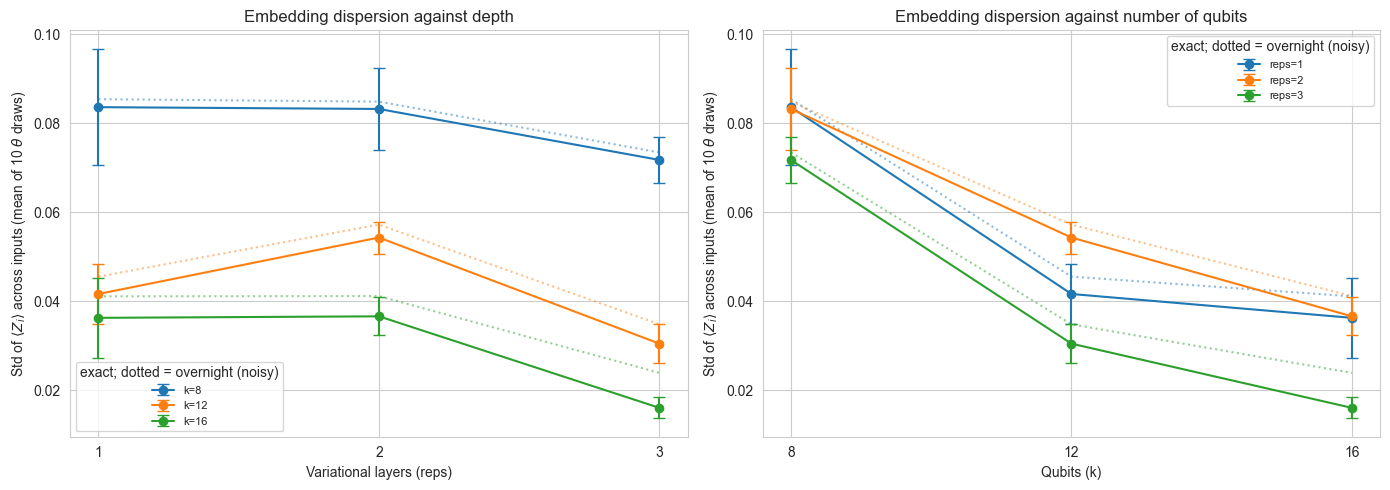

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (k, g) in enumerate(conc.groupby("k")):
    axes[0].errorbar(g.reps, g.std_media, yerr=g.std_de_std, fmt="-o", capsize=4, color=f"C{i}", label=f"k={k}")
    n = night[night.k == k]
    axes[0].plot(n.reps, n.std_media, ":", color=f"C{i}", alpha=0.5)
for i, (reps, g) in enumerate(conc.groupby("reps")):
    axes[1].errorbar(g.k, g.std_media, yerr=g.std_de_std, fmt="-o", capsize=4, color=f"C{i}", label=f"reps={reps}")
    n = night[night.reps == reps]
    axes[1].plot(n.k, n.std_media, ":", color=f"C{i}", alpha=0.5)
axes[0].set_xlabel("Variational layers (reps)")
axes[0].set_xticks(list(REPS_VALUES))
axes[1].set_xlabel("Qubits (k)")
axes[1].set_xticks(list(K_VALUES))
for a in axes:
    a.set_ylabel(rf"Std of $\langle Z_i \rangle$ across inputs (mean of {N_THETA} $\theta$ draws)")
    a.legend(title="exact; dotted = overnight (noisy)", fontsize=8)
axes[0].set_title("Embedding dispersion against depth")
axes[1].set_title("Embedding dispersion against number of qubits")
plt.tight_layout()
plt.savefig(FIG_DIR / "E4_embedding_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

**d.** Consequence

The diagnosis holds: adding the default noise back to the exact values reproduces the
overnight numbers to the third decimal. The noise inflated every dispersion, by about 2 %
at $k = 8$ and by 49 % at $k = 16$ with `reps=3`, where it made up 43 % of the measured
variance: the smaller the true dispersion, the larger the distortion.

The three readings of H-018 survive, with corrected numbers:

1. **Concentration with the number of qubits is clear.** At `reps=1` the dispersion falls
   from $0.084$ ($k = 8$) to $0.042$ ($k = 12$) and $0.036$ ($k = 16$). From 8 to 12 it
   halves, far outside the error bars; from 12 to 16 the change is within them.
2. **Depth is not monotone between 1 and 3 layers.** `reps=1` and `reps=2` are
   indistinguishable at $k = 8$ and $k = 16$, and at $k = 12$ `reps=2` is about 30 % more
   dispersed than `reps=1` ($0.054 \pm 0.004$ against $0.042 \pm 0.007$), with bars that do
   not overlap. Only `reps=3` is consistently lower, and at $k = 16$ it more than halves
   the dispersion.
3. **The variability between $\theta$ draws collapses with depth.** At $k = 16$ it goes
   $0.0090 \to 0.0043 \to 0.0023$. The loss of sensitivity to the parameters is the
   signature of a barren plateau, and it is clearer without the noise than with it.

One claim of H-018 does **not** survive at the operating point: `reps=1` does not give the
largest dispersion at $k = 12$; `reps=2` does. The case for `reps=1` rests on cost and on
D-014 (θ is not trained), not on dispersion. Dispersion is in any case only a proxy:
whether it turns into separability is what Module 7 measures.

#### **6° Summary**

In [11]:
row = lambda k, reps: conc[(conc.k == k) & (conc.reps == reps)].iloc[0]
print("=" * 70)
print("SAMPLING NOISE & EMBEDDING CONCENTRATION - SUMMARY")
print("=" * 70)
print("  1. The 0.013 floor of H-016 is not a simulator bias.")
print(f"     Aer at precision 0 vs direct statevector: MAE {floor.loc[3, 'mae']:.1e}")
print(f"     The 'exact' reference carried the EstimatorQNN default precision:")
print(f"     sqrt(2/pi) * {QNN_DEFAULT_PRECISION} = {np.sqrt(2 / np.pi) * QNN_DEFAULT_PRECISION:.5f}")
print()
print("  2. Aer's EstimatorV2 does not sample: exact value + N(0, precision).")
print(f"     At 16 shots: {coarse.iloc[0, 1]:.0%} of its values on the 1/8 grid, "
      f"{coarse.iloc[0, 2]:.0%} outside [-1, 1].")
print()
print("  3. Genuine sampling follows sqrt((1 - <Z>^2)/n) with no floor.")
print(f"     Slopes: dispersion {slope_disp:.4f}, MAE {slope_mae:.4f} (theory -0.5), "
      f"{SHOTS_GRID[0]} to {SHOTS_GRID[-1]} shots.")
print()
print("  4. Embedding dispersion with exact values (reps=1):")
for k in K_VALUES:
    r = row(k, 1)
    print(f"     k={k:2d}: {r.std_media:.4f} +/- {r.std_de_std:.4f}")
print("=" * 70)

SAMPLING NOISE & EMBEDDING CONCENTRATION - SUMMARY
  1. The 0.013 floor of H-016 is not a simulator bias.
     Aer at precision 0 vs direct statevector: MAE 1.7e-16
     The 'exact' reference carried the EstimatorQNN default precision:
     sqrt(2/pi) * 0.015625 = 0.01247

  2. Aer's EstimatorV2 does not sample: exact value + N(0, precision).
     At 16 shots: 0% of its values on the 1/8 grid, 0% outside [-1, 1].

  3. Genuine sampling follows sqrt((1 - <Z>^2)/n) with no floor.
     Slopes: dispersion -0.4986, MAE -0.4983 (theory -0.5), 512 to 1048576 shots.

  4. Embedding dispersion with exact values (reps=1):
     k= 8: 0.0837 +/- 0.0131
     k=12: 0.0417 +/- 0.0068
     k=16: 0.0363 +/- 0.0090
